# Hotel Harmony: Data Insights for Optimized Operations

**Company:** Elite Hotels International  
**Project type:** Fresher-level end-to-end Data Analyst project  
**Dataset:** Hotel Booking Demand

This notebook follows the supplied case study **line by line and question by question**:
- Data loading
- Data understanding
- Data cleaning
- EDA
- 10 Basic questions
- 10 Medium questions
- 5 Advanced questions
- Final business conclusions and recommendations

> Important: The supplied case study calls `ADR` a revenue metric. For the specific question "Which month has the highest revenue?", the notebook first follows the case-study instruction and sums `adr`. It also calculates a more useful lodging-revenue proxy as `adr × total nights` for additional analysis.


## 1. Problem Definition

Elite Hotels International wants to optimize booking patterns and improve customer satisfaction. The analysis should help management understand:
- booking behavior
- cancellations
- hotel and room demand
- market segments and channels
- guest preferences
- ADR and revenue patterns
- factors associated with cancellation

The source case study identifies management, operations, marketing and customer service as internal stakeholders, with guests, travel agencies and suppliers as external stakeholders.


In [10]:
# Import the libraries required for the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [11]:
# Read the CSV file

file_path = "/content/hotel_bookings.csv"
df = pd.read_csv(file_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()


Rows: 119390
Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0000,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0000,NaN,0,Transient,98.0000,0,1,Check-Out,2015-07-03


In [12]:
# Understand the structure of the dataset

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())


Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nigh

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0000,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0000,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0000,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0000,NaN,0,Transient,75.0000,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0000,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0000,NaN,0,Transient,98.0000,0,1,Check-Out,2015-07-03


In [13]:
# Basic statistical summary

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,"119,390.0000",NaN,NaN,NaN,0.3704,0.4829,0.0000,0.0000,0.0000,1.0000,1.0000
lead_time,"119,390.0000",NaN,NaN,NaN,104.0114,106.8631,0.0000,18.0000,69.0000,160.0000,737.0000
arrival_date_year,"119,390.0000",NaN,NaN,NaN,"2,016.1566",0.7075,"2,015.0000","2,016.0000","2,016.0000","2,017.0000","2,017.0000"
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,"119,390.0000",NaN,NaN,NaN,27.1652,13.6051,1.0000,16.0000,28.0000,38.0000,53.0000
arrival_date_day_of_month,"119,390.0000",NaN,NaN,NaN,15.7982,8.7808,1.0000,8.0000,16.0000,23.0000,31.0000
stays_in_weekend_nights,"119,390.0000",NaN,NaN,NaN,0.9276,0.9986,0.0000,0.0000,1.0000,2.0000,19.0000
stays_in_week_nights,"119,390.0000",NaN,NaN,NaN,2.5003,1.9083,0.0000,1.0000,2.0000,3.0000,50.0000
adults,"119,390.0000",NaN,NaN,NaN,1.8564,0.5793,0.0000,2.0000,2.0000,2.0000,55.0000


## 2. Data Cleaning

The case study specifically asks us to:
1. Handle missing values in `agent`, `company`, and `children`.
2. Convert date columns to datetime.
3. Check and handle duplicate rows.

For `children`, missing means no child count was supplied, so we use `0`.  
For `agent` and `company`, `0` is used as an explicit "no agent/company recorded" value for analysis.


In [14]:
# Check missing values before cleaning

missing_before = df.isnull().sum().sort_values(ascending=False)
missing_before[missing_before > 0]


,0
company,112593
agent,16340
country,488
children,4


In [15]:
# Fill the missing values requested in the case study
df["children"] = df["children"].fillna(0)
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

# Convert date column with mixed formats safely
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"], format="mixed", errors="coerce"
)

# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

# Remove exact duplicate rows
df = df.drop_duplicates().copy()
print("Rows after removing duplicates:", len(df))

Duplicate rows found: 31994
Rows after removing duplicates: 87396


In [16]:
# Final missing-value check

missing_after = df.isnull().sum().sort_values(ascending=False)
missing_after[missing_after > 0]


,0
country,452


In [17]:
# Create a useful derived metric: total stay duration

df["total_stay_nights"] = (
    df["stays_in_week_nights"] + df["stays_in_weekend_nights"]
)

# Create a lodging revenue proxy
df["estimated_lodging_revenue"] = df["adr"] * df["total_stay_nights"]

df[["stays_in_week_nights", "stays_in_weekend_nights",
    "total_stay_nights", "adr", "estimated_lodging_revenue"]].head()


,stays_in_week_nights,stays_in_weekend_nights,total_stay_nights,adr,estimated_lodging_revenue
0,0,0,0,0.0000,0.0000
1,0,0,0,0.0000,0.0000
2,1,0,1,75.0000,75.0000
3,1,0,1,75.0000,75.0000
4,2,0,2,98.0000,196.0000


# 3. Exploratory Data Analysis

The case study asks us to analyze:
- hotel type
- month
- market segment
- lead time vs cancellation
- ADR over time
- special requests


hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64


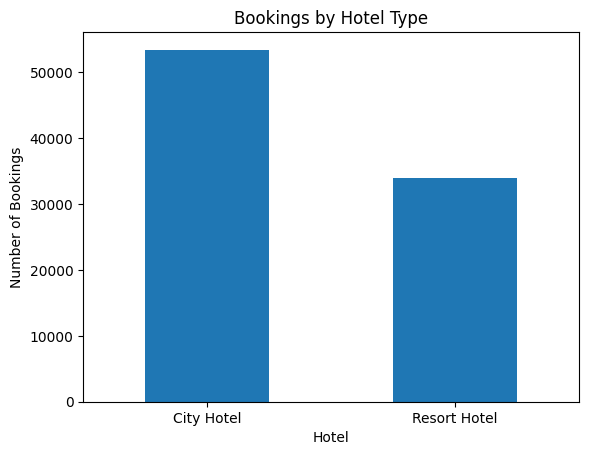

In [18]:
# Distribution of bookings by hotel type

hotel_counts = df["hotel"].value_counts()
print(hotel_counts)

hotel_counts.plot(kind="bar", title="Bookings by Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.show()


In [19]:
# Distribution of bookings by arrival month

month_counts = df["arrival_date_month"].value_counts()
month_counts


,count
arrival_date_month,
August,11257
July,10057
May,8355
April,7908
June,7765
March,7513
October,6934
September,6690
February,6098


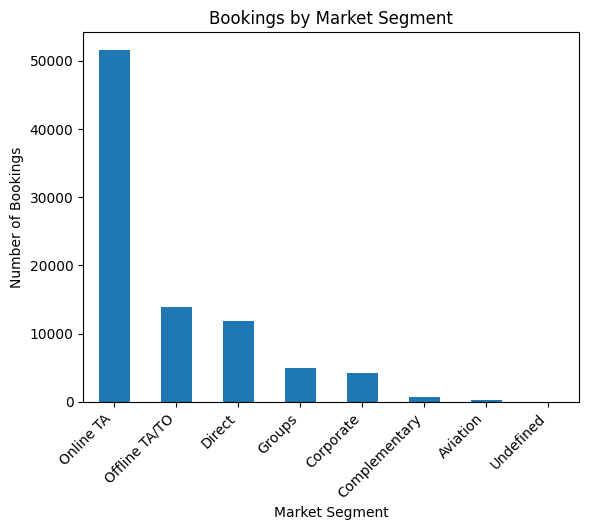

In [20]:
# Market segment distribution

market_counts = df["market_segment"].value_counts()
market_counts.plot(kind="bar", title="Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45, ha="right")
plt.show()


# 4. Basic Level Questions

### 1. What is the average lead time for bookings?

In [21]:
average_lead_time = df["lead_time"].mean()
print(f"Average lead time: {average_lead_time:.2f} days")

Average lead time: 79.89 days


### 2. What is the distribution of bookings by hotel type?

In [22]:
hotel_distribution = df["hotel"].value_counts()
print(hotel_distribution)

hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64


### 3. How many bookings were canceled?

In [23]:
canceled_bookings = df["is_canceled"].sum()
print(f"Canceled bookings: {canceled_bookings:,}")

Canceled bookings: 24,025


### 4. What is the most common arrival month for bookings?

In [24]:
most_common_month = df["arrival_date_month"].mode()[0]
print("Most common arrival month:", most_common_month)

Most common arrival month: August


### 5. What is the average number of special requests per booking?

In [25]:
avg_special_requests = df["total_of_special_requests"].mean()
print(f"Average special requests per booking: {avg_special_requests:.2f}")

Average special requests per booking: 0.70


### 6. Which country has the highest number of bookings?

In [26]:
top_country = df["country"].value_counts().idxmax()
top_country_count = df["country"].value_counts().max()
print(f"Top country: {top_country} ({top_country_count:,} bookings)")

Top country: PRT (27,453 bookings)


### 7. What is the average daily rate (ADR) for each hotel type?

In [27]:
avg_adr_hotel = df.groupby("hotel")["adr"].mean().sort_values(ascending=False)
print(avg_adr_hotel)

hotel
City Hotel     110.9859
Resort Hotel    99.0253
Name: adr, dtype: float64


### 8. What percentage of guests required car parking spaces?

In [28]:
parking_percentage = (df["required_car_parking_spaces"] > 0).mean() * 100
print(f"Bookings requiring parking: {parking_percentage:.2f}%")

Bookings requiring parking: 8.37%


### 9. What is the average stay duration in week nights and weekend nights?

In [29]:
avg_week_nights = df["stays_in_week_nights"].mean()
avg_weekend_nights = df["stays_in_weekend_nights"].mean()
print(f"Average week nights: {avg_week_nights:.2f}")
print(f"Average weekend nights: {avg_weekend_nights:.2f}")

Average week nights: 2.63
Average weekend nights: 1.01


### 10. How many bookings were made through travel agents?

In [30]:
# In this dataset, a non-zero agent ID means an agent was recorded.
agent_bookings = (df["agent"] > 0).sum()
print(f"Bookings with a travel-agent ID: {agent_bookings:,}")

Bookings with a travel-agent ID: 75,203


# 5. Medium Level Questions

### 1. What is the cancellation rate for each hotel type?

In [31]:
cancellation_by_hotel = (
    df.groupby("hotel")["is_canceled"].mean().mul(100).sort_values(ascending=False)
)
print(cancellation_by_hotel.round(2).astype(str) + "%")

hotel
City Hotel      30.04%
Resort Hotel    23.48%
Name: is_canceled, dtype: object


### 2. What is the average ADR per market segment?

In [32]:
avg_adr_segment = (
    df.groupby("market_segment")["adr"].mean().sort_values(ascending=False)
)
print(avg_adr_segment.round(2))

market_segment
Online TA       118.1700
Direct          116.5800
Aviation        100.1700
Offline TA/TO    81.7600
Groups           74.8600
Corporate        68.1500
Undefined        15.0000
Complementary     3.0500
Name: adr, dtype: float64


### 3. What is the relationship between lead time and cancellation rate?

lead_time_group
0-30      16.4200
31-60     31.6200
61-90     32.5600
91-180    34.9800
181-365   39.6800
366+      40.8800
Name: is_canceled, dtype: float64


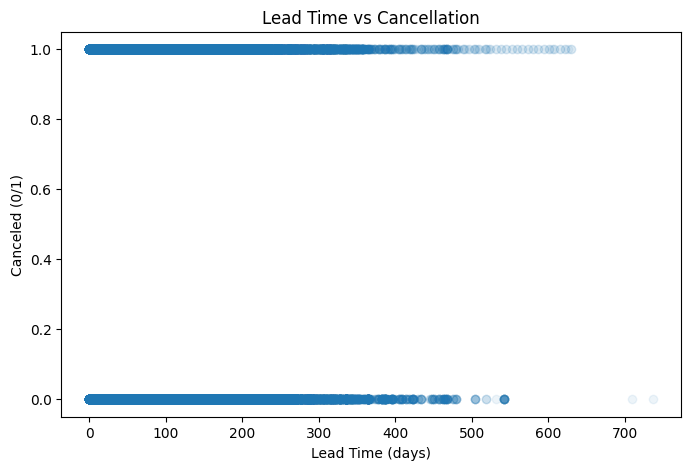

Pearson correlation: 0.1848055877733435


In [33]:
# A scatter plot of every row against a binary cancellation flag is dense,
# so we also calculate cancellation rate by lead-time bucket.
bins = [0, 30, 60, 90, 180, 365, np.inf]
labels = ["0-30", "31-60", "61-90", "91-180", "181-365", "366+"]

df["lead_time_group"] = pd.cut(
    df["lead_time"], bins=bins, labels=labels, include_lowest=True
)

lead_cancel = df.groupby("lead_time_group", observed=False)["is_canceled"].mean() * 100
print(lead_cancel.round(2))

plt.figure(figsize=(8, 5))
plt.scatter(df["lead_time"], df["is_canceled"], alpha=0.08)
plt.xlabel("Lead Time (days)")
plt.ylabel("Canceled (0/1)")
plt.title("Lead Time vs Cancellation")
plt.show()

print("Pearson correlation:", df[["lead_time", "is_canceled"]].corr().iloc[0, 1])

### 4. Which distribution channel has the highest number of bookings?

In [34]:
channel_counts = df["distribution_channel"].value_counts()
print(channel_counts)
print("Highest:", channel_counts.idxmax())

distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64
Highest: TA/TO


### 5. What is the average number of previous cancellations by hotel type?

In [35]:
previous_cancel_by_hotel = (
    df.groupby("hotel")["previous_cancellations"].mean()
)
print(previous_cancel_by_hotel.round(4))

hotel
City Hotel     0.0358
Resort Hotel   0.0220
Name: previous_cancellations, dtype: float64


### 6. What is the trend of ADR over the years?

arrival_date_year
2015    92.1600
2016   101.5400
2017   118.7100
Name: adr, dtype: float64


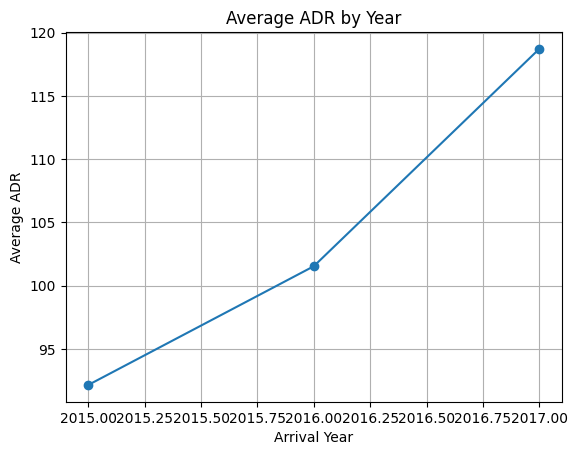

In [36]:
adr_by_year = df.groupby("arrival_date_year")["adr"].mean()
print(adr_by_year.round(2))

adr_by_year.plot(kind="line", marker="o", title="Average ADR by Year")
plt.xlabel("Arrival Year")
plt.ylabel("Average ADR")
plt.grid(True)
plt.show()

### 7. Which month has the highest revenue?

In [37]:
# Follow the case-study instruction: sum ADR by arrival month.
adr_sum_by_month = (
    df.groupby("arrival_date_month")["adr"].sum()
    .sort_values(ascending=False)
)
print("Case-study ADR-sum ranking:")
print(adr_sum_by_month.round(2))

# Additional, more meaningful lodging revenue proxy:
revenue_by_month = (
    df.groupby("arrival_date_month")["estimated_lodging_revenue"].sum()
    .sort_values(ascending=False)
)
print("\nEstimated lodging revenue proxy ranking:")
print(revenue_by_month.round(2))

Case-study ADR-sum ranking:
arrival_date_month
August      1,698,412.4800
July        1,363,146.0300
June          929,859.6800
May           929,040.1000
April         819,368.3500
September     749,823.6500
October       625,117.5600
March         613,132.3500
February      455,472.0200
December      417,921.1100
November      363,408.5300
January       328,748.1300
Name: adr, dtype: float64

Estimated lodging revenue proxy ranking:
arrival_date_month
August      7,240,652.9900
July        5,863,024.9900
June        3,496,345.0500
May         3,123,058.2200
April       2,787,157.0500
September   2,689,186.1900
March       2,048,685.3300
October     2,032,649.2500
February    1,473,600.2000
December    1,407,704.1700
November    1,219,278.3500
January     1,079,597.5200
Name: estimated_lodging_revenue, dtype: float64


### 8. What is the impact of special requests on ADR?

Correlation between special requests and ADR: 0.1378


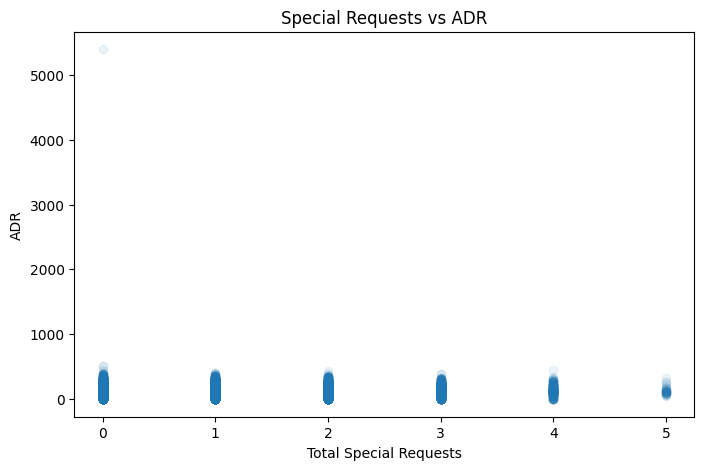

In [38]:
corr_special_adr = df[["total_of_special_requests", "adr"]].corr().iloc[0, 1]
print(f"Correlation between special requests and ADR: {corr_special_adr:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(
    df["total_of_special_requests"], df["adr"],
    alpha=0.08
)
plt.xlabel("Total Special Requests")
plt.ylabel("ADR")
plt.title("Special Requests vs ADR")
plt.show()

### 9. What is the average stay duration for repeated guests versus new guests?

In [39]:
stay_by_guest_type = (
    df.groupby("is_repeated_guest")["total_stay_nights"].mean()
)
stay_by_guest_type.index = ["New Guest", "Repeated Guest"]
print(stay_by_guest_type.round(2))

New Guest        3.7000
Repeated Guest   1.9300
Name: total_stay_nights, dtype: float64


### 10. Which room type has the highest number of bookings?

In [40]:
room_counts = df["reserved_room_type"].value_counts()
print(room_counts)
print("Most booked room type:", room_counts.idxmax())

reserved_room_type
A    56552
D    17398
E     6049
F     2823
G     2052
B      999
C      915
H      596
L        6
P        6
Name: count, dtype: int64
Most booked room type: A


# 6. Advanced Level Questions

For the advanced section, the notebook uses statistical models rather than only descriptive statistics.

- Logistic regression → cancellation probability
- Multiple linear regression → ADR
- Correlation → booking changes and special requests
- Monthly cancellation rates → seasonality
- Box plot → lead-time distribution by market segment


### 1. What factors significantly impact the cancellation rate?

In [41]:
# Logistic regression.
# Positive coefficient -> higher cancellation odds.
# Negative coefficient -> lower cancellation odds.

logit_features = [
    "lead_time",
    "booking_changes",
    "total_of_special_requests",
    "previous_cancellations"
]

X = sm.add_constant(df[logit_features])
y = df["is_canceled"]

logit_model = sm.Logit(y, X).fit(disp=False)

logit_results = pd.DataFrame({
    "coefficient": logit_model.params,
    "odds_ratio": np.exp(logit_model.params),
    "p_value": logit_model.pvalues
})

logit_results["significant_at_5pct"] = logit_results["p_value"] < 0.05
print(logit_results.round(6))

print("\nPseudo R-squared:", round(logit_model.prsquared, 4))

                           coefficient  odds_ratio  p_value  \
const                          -1.0576      0.3473   0.0000   
lead_time                       0.0050      1.0050   0.0000   
booking_changes                -0.4930      0.6108   0.0000   
total_of_special_requests      -0.3869      0.6792   0.0000   
previous_cancellations          0.4425      1.5565   0.0000   

                           significant_at_5pct  
const                                     True  
lead_time                                 True  
booking_changes                           True  
total_of_special_requests                 True  
previous_cancellations                    True  

Pseudo R-squared: 0.0573


### 2. How does ADR vary with the number of adults, children, and babies?

In [42]:
# Multiple linear regression
adr_features = ["adults", "children", "babies"]

X_adr = sm.add_constant(df[adr_features])
y_adr = df["adr"]

adr_model = sm.OLS(y_adr, X_adr).fit()

adr_results = pd.DataFrame({
    "coefficient": adr_model.params,
    "p_value": adr_model.pvalues
})

print(adr_results.round(6))
print("\nR-squared:", round(adr_model.rsquared, 4))

          coefficient  p_value
const         61.1803   0.0000
adults        21.1778   0.0000
children      38.6573   0.0000
babies         6.7081   0.0000

R-squared: 0.1649


### 3. What is the impact of booking changes on guest satisfaction as indicated by special requests?

Correlation: 0.0161


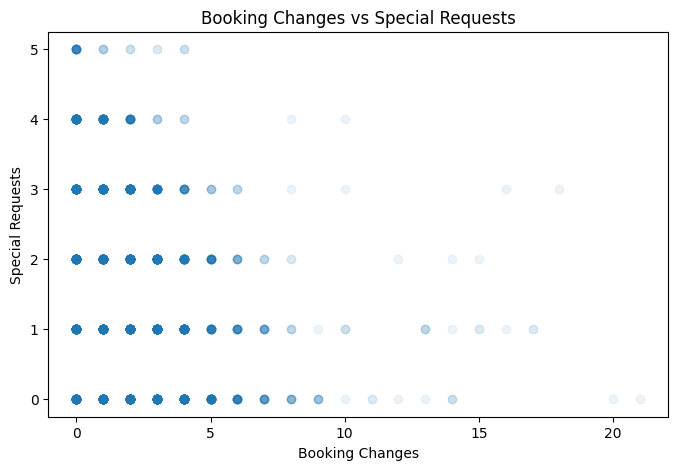

In [43]:
change_request_corr = df[
    ["booking_changes", "total_of_special_requests"]
].corr().iloc[0, 1]

print(f"Correlation: {change_request_corr:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(
    df["booking_changes"], df["total_of_special_requests"],
    alpha=0.08
)
plt.xlabel("Booking Changes")
plt.ylabel("Special Requests")
plt.title("Booking Changes vs Special Requests")
plt.show()

### 4. What is the seasonal impact on booking cancellations?

arrival_date_month
January     22.1200
February    23.2000
March       24.3600
April       30.4600
May         29.2300
June        30.3200
July        31.8000
August      32.1800
September   24.5400
October     23.6800
November    21.1000
December    26.8600
Name: is_canceled, dtype: float64


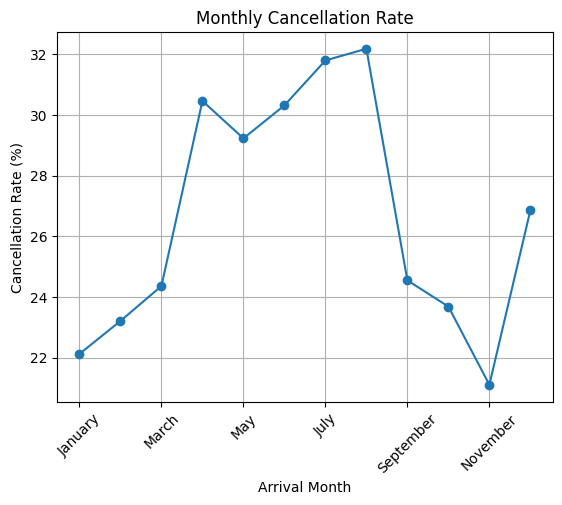

In [44]:
seasonal_cancellation = (
    df.groupby("arrival_date_month")["is_canceled"].mean().mul(100)
)

# Put months into calendar order.
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

seasonal_cancellation = seasonal_cancellation.reindex(month_order)
print(seasonal_cancellation.round(2))

seasonal_cancellation.plot(
    kind="line", marker="o",
    title="Monthly Cancellation Rate"
)
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 5. How does the booking lead-time distribution vary between different market segments?

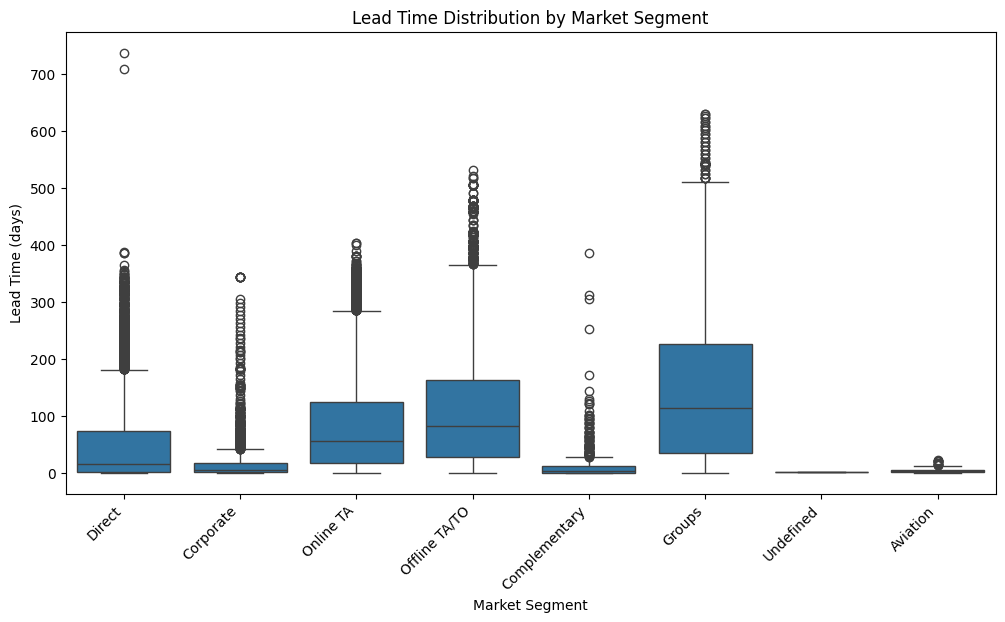

,count,mean,median,min,max
market_segment,,,,,
Groups,4942,147.6100,114.0000,0,629
Offline TA/TO,13889,106.0500,82.0000,0,532
Online TA,51618,79.9000,55.0000,0,403
Direct,11804,48.8300,15.0000,0,737
Corporate,4212,16.2500,5.0000,0,343
Complementary,702,13.6400,3.0000,0,386
Aviation,227,4.2800,3.0000,0,23
Undefined,2,1.5000,1.5000,1,2


In [45]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="market_segment",
    y="lead_time"
)
plt.title("Lead Time Distribution by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Lead Time (days)")
plt.xticks(rotation=45, ha="right")
plt.show()

lead_time_by_segment = (
    df.groupby("market_segment")["lead_time"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)
lead_time_by_segment.round(2)

# 7. Key Findings

The exact values are generated directly from the supplied `hotel_bookings.csv` after the requested cleaning steps.

The main business themes to discuss in an interview are:

1. **Booking lead time:** Use the average lead time to understand how early inventory is committed.
2. **Cancellations:** Compare cancellation rates between City and Resort hotels and identify high-risk booking patterns.
3. **Seasonality:** August is the most common arrival month in this dataset; monthly cancellation rates should guide staffing and inventory decisions.
4. **Revenue / ADR:** ADR differs by hotel type, market segment and year. Pricing should therefore be segment-aware rather than one-size-fits-all.
5. **Channels:** The dominant distribution channel represents an important commercial relationship and should be monitored for both volume and cancellation quality.
6. **Guest behavior:** Repeated guests have a different stay-duration pattern from new guests, supporting targeted loyalty strategies.
7. **Special requests:** The relationship with ADR is positive but should not be interpreted as causation.
8. **Cancellation drivers:** Logistic regression helps quantify which variables are statistically associated with cancellation.


# 8. Business Recommendations

### Management
- Use monthly demand and cancellation patterns for capacity and staffing planning.
- Review cancellation-risk segments before accepting very long lead-time bookings.

### Operations
- Plan room inventory around high-demand arrival periods.
- Use special-request volume to forecast service workload and room-preparation needs.
- Monitor parking demand when planning guest facilities.

### Marketing
- Prioritize high-volume markets and channels, but evaluate profitability and cancellation rate—not volume alone.
- Build loyalty campaigns for repeat guests.

### Revenue Management
- Monitor ADR by hotel, year, month and market segment.
- Use demand patterns to adjust pricing and promotional campaigns.
- For revenue reporting, prefer actual room-night revenue where available; `ADR × nights` is only an estimate/proxy in this dataset.

### Customer Service
- Use special-request patterns to anticipate guest needs.
- Investigate whether booking changes are linked to operational friction, while remembering that correlation does not prove causation.


# 9. Interview Explanation: End-to-End Flow

A fresher can explain the project in this order:

**1. Business Problem → 2. Data Collection → 3. Data Understanding → 4. Data Cleaning → 5. Feature Creation → 6. EDA → 7. Basic Analysis → 8. Advanced Statistical Analysis → 9. Insights → 10. Business Recommendations**

Example interview statement:

> "I worked on a hotel booking analysis project for Elite Hotels International. I first loaded the CSV using pandas and inspected its shape, columns, data types and missing values. I handled the requested missing values, converted the reservation status date to datetime, checked duplicates and removed exact duplicates. Then I created total stay duration and an estimated lodging-revenue metric. I performed EDA on hotel type, arrival month, market segment, lead time, cancellations and ADR. After answering the basic and medium business questions, I used logistic regression to identify variables associated with cancellation and multiple linear regression to study ADR against adults, children and babies. Finally, I converted the results into recommendations for operations, marketing, customer service and revenue management."


## Source Case Study Coverage

This notebook is based on the supplied case-study document, which defines the dataset, data dictionary, stakeholders, problem definition, preprocessing steps, Basic/Medium/Advanced questions and deliverables. fileciteturn0file0L5-L11

The supplied data dictionary defines fields such as `hotel`, `is_canceled`, `lead_time`, arrival-date fields, stay duration, guest counts, market segment, distribution channel, ADR and reservation status. fileciteturn0file0L15-L46

The preprocessing and question sections specifically request missing-value handling, datetime conversion, duplicate handling, EDA, 10 Basic questions, 10 Medium questions and 5 Advanced questions. fileciteturn0file0L105-L115 fileciteturn0file0L117-L169 fileciteturn0file0L170-L221 fileciteturn0file0L223-L249
